### Image Classification using Transfer Learning

**Dataset:** Oxford-IIIT Pet

**Pretrained Model:** ResNet18

**Transfer Learning Techniques:**
- Feature Extraction
- Fine-Tuning

**Objective:**
Compare Feature Extraction and Fine-Tuning using a pretrained ResNet18 model on the Oxford-IIIT Pet dataset.

In [3]:
import torch #pytorch is the main deep learning library
import torchvision #it is a library specially made for computer vision

from torchvision import datasets #to download and load image datasets
from torchvision import transforms #we need to transform images to format that model can use because cnns cant understand jpegs or pngs
from torchvision import models # to use pretrained models
from torch.utils.data import DataLoader #it will make batches of data so that we can feed it to the model

import torch.nn as nn #nn contains the neural network and loss functions 
import torch.optim as optim #optim is we can say optimizer which make the model learn from the data
import matplotlib.pyplot as plt #to plot the images and graphs 
import numpy as np


from sklearn.metrics import(
        confusion_matrix,               #which classes are being confused with each other
        classification_report,          #how well the model is performing in each class
        accuracy_score                  #to measure the prediction accuracy of the model
)

print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)

PyTorch Version: 2.11.0+cu128
Torchvision Version: 0.26.0+cu128


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device using: ", device)
# this code is used to use gpu if available otherwise it will cpu now we have gpu nvidia cuda 
# so we are using cuda

device using:  cuda


In [ ]:
print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())
print("CUDA Version    :", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU Name        :", torch.cuda.get_device_name(0))

PyTorch Version : 2.11.0+cu128
CUDA Available  : True
CUDA Version    : 12.8
GPU Name        : NVIDIA GeForce RTX 3050 6GB Laptop GPU


Oxford-IIIT Pet Dataset 

I chose this dataset because according to chatGPT this project had the potential to make me understand most of the basics and understanding for the CNN projects. this is one of the best dataset to work on as beginner as you get to learn many of the things.

In [4]:
#now we gonna download the dataset 
train_dataset = datasets.OxfordIIITPet(
        root = "../data", #this is the path where the dataset will be downloaded because lets keep it organised
        split = "trainval", #we want the trainig and validation data
        target_types = "category", #we want the category of the image
        download = True
)

100%|██████████| 792M/792M [07:02<00:00, 1.88MB/s]  
100%|██████████| 19.2M/19.2M [00:17<00:00, 1.12MB/s]


In [ ]:
print("Training dataset size:", len(train_dataset))
#this is to check the training sample data size 

Training dataset size: 3680


In [23]:
image ,label = train_dataset[0] #this is to check the first image and its label
print(type(image))
print(type(label))

<class 'PIL.Image.Image'>
<class 'int'>


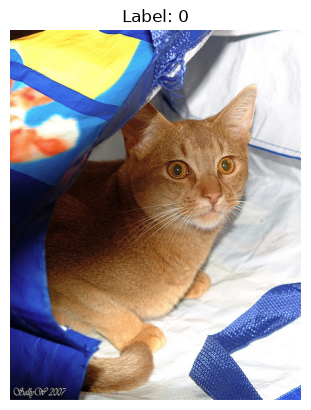

In [24]:
plt.imshow(image) #this is to show the image
plt.title(f"Label: {label}") #this is to show the label of the image
plt.axis("off") #this is to remove the axis from the image
plt.show() #this is to show the image